1. Data Exploration & Preprocessing

In [65]:
import pandas as pd

df = pd.read_csv("/content/single_genre_artists.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [66]:
print(df.columns)

print(df.shape)

Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'name_artists', 'popularity_artists'],
      dtype='object')
(95837, 23)


Dropped unnecessary columns:


In [67]:
import pandas as pd

df_clean = df.drop(columns=['name_song', 'name_artists', 'id_songs', 'followers',
    'popularity_songs',
    'popularity_artists',
    'id_artists', 'release_date', 'genres',
    'explicit',
    'key',
    'mode',
    'time_signature'],  errors='ignore')
print(df_clean.columns)

df_clean.to_csv("Cleaned.csv", index = False)
print("downloaded the cleaned csv")

print(df_clean.shape)

Index(['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'],
      dtype='object')
downloaded the cleaned csv
(95837, 10)


In [68]:
df_clean.dropna(inplace=True)
df_clean.isnull().sum()

,0
duration_ms,0
danceability,0
energy,0
loudness,0
speechiness,0
acousticness,0
instrumentalness,0
liveness,0
valence,0
tempo,0


Visualize distributions of key features to understand variation in values.


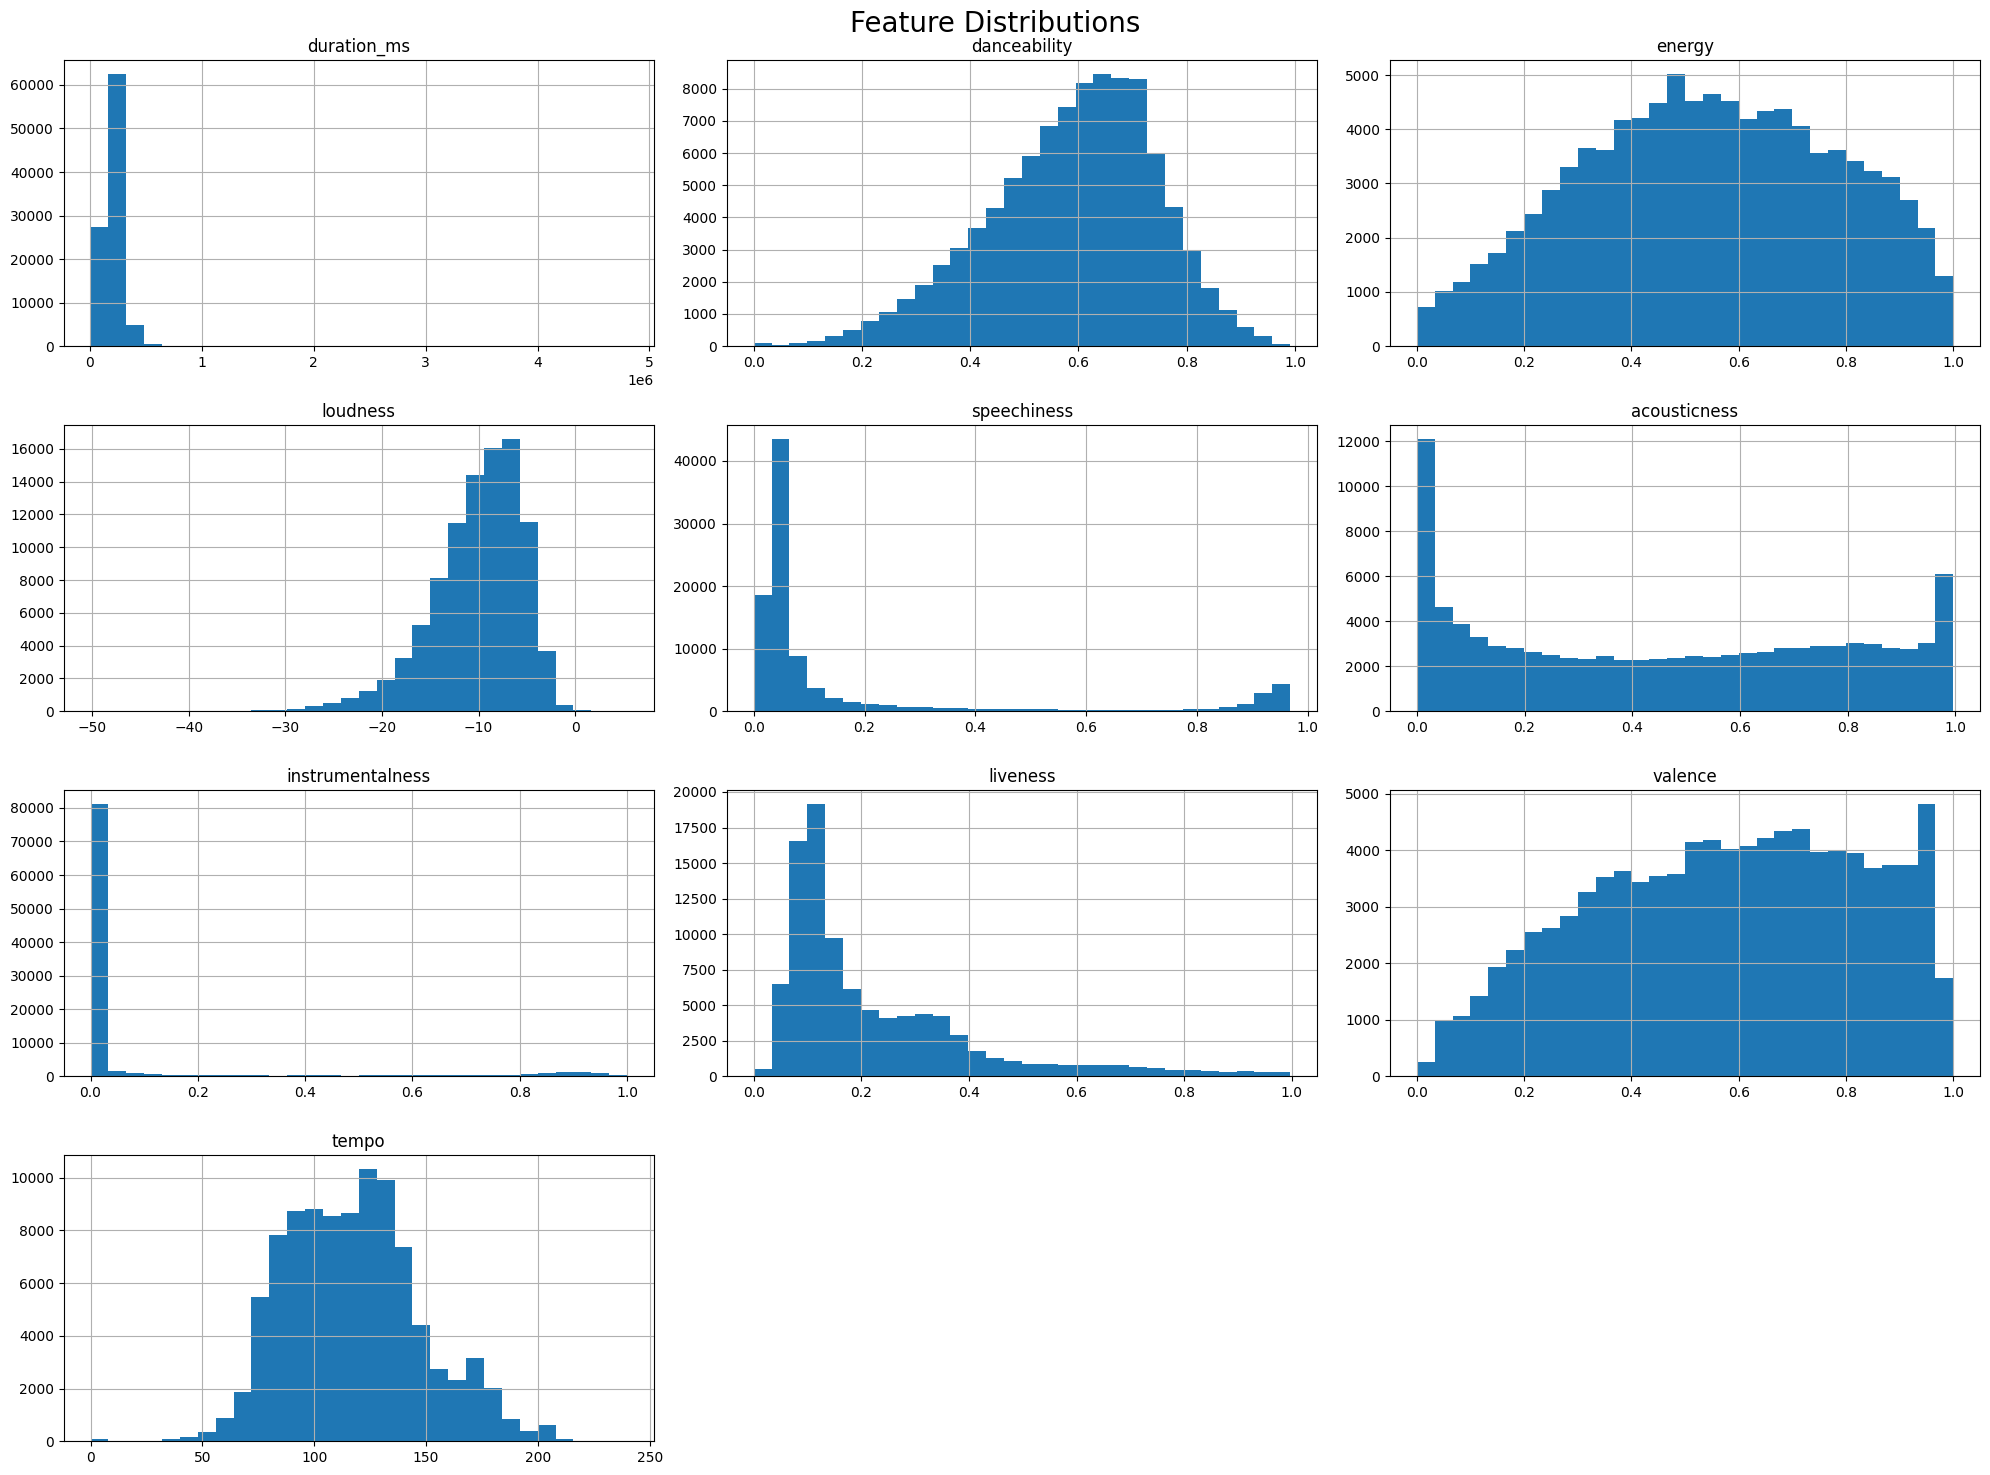

In [69]:
import matplotlib.pyplot as plt

df_clean.hist(figsize=(20, 15), bins=30)
plt.suptitle("Feature Distributions", fontsize=20)

plt.tight_layout()
plt.show()

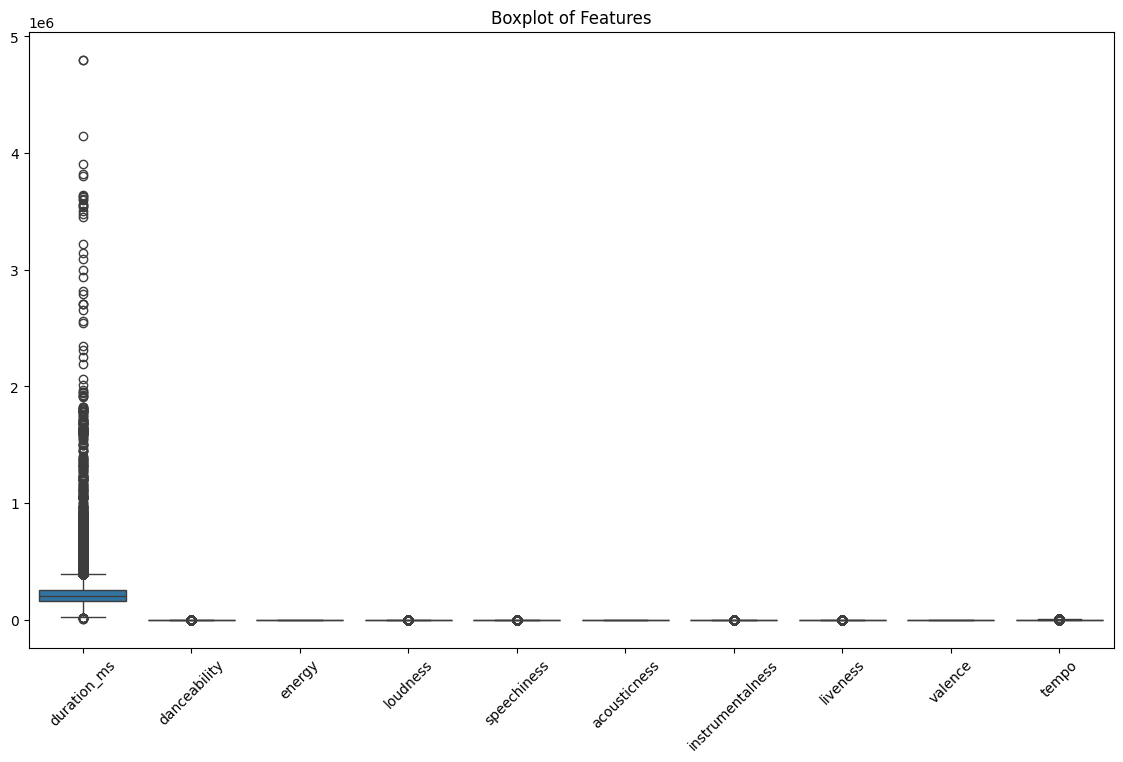

In [70]:
import seaborn as sns

plt.figure(figsize=(14,8))
sns.boxplot(data=df_clean)
plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.show()

Visualize distributions of key features to understand variation in values.


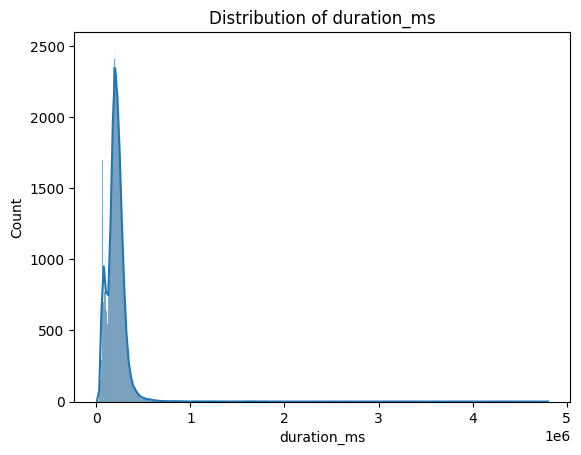

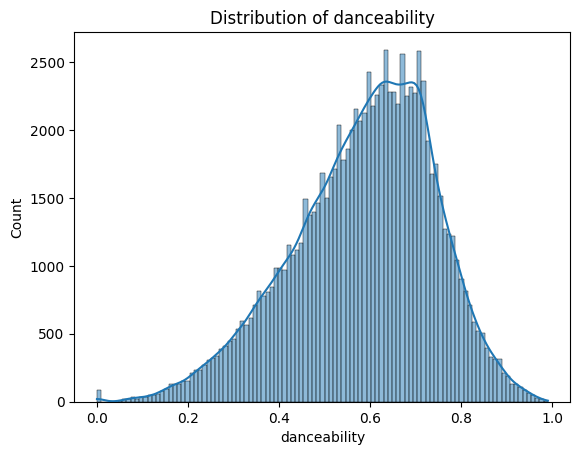

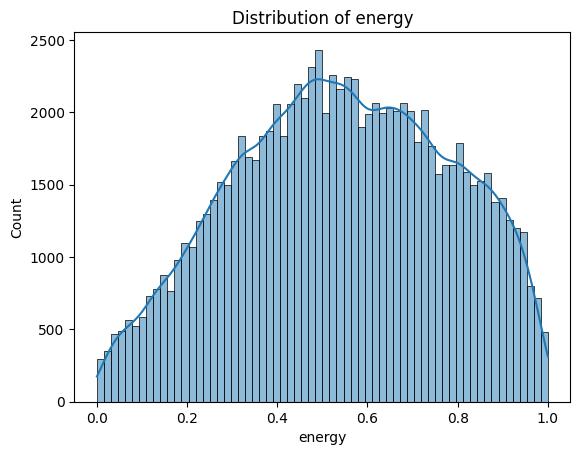

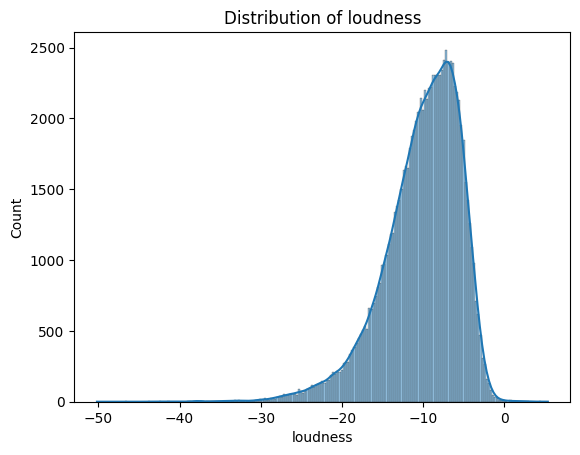

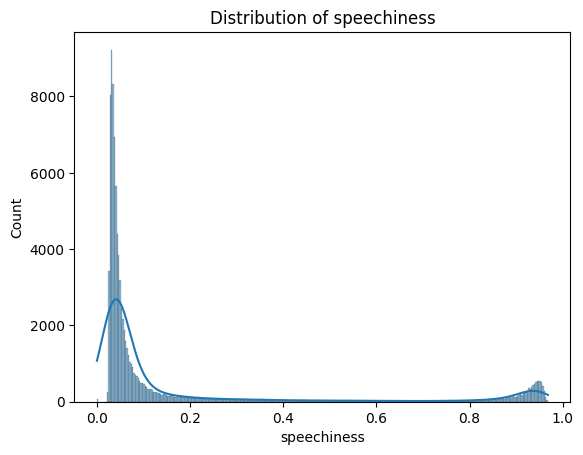

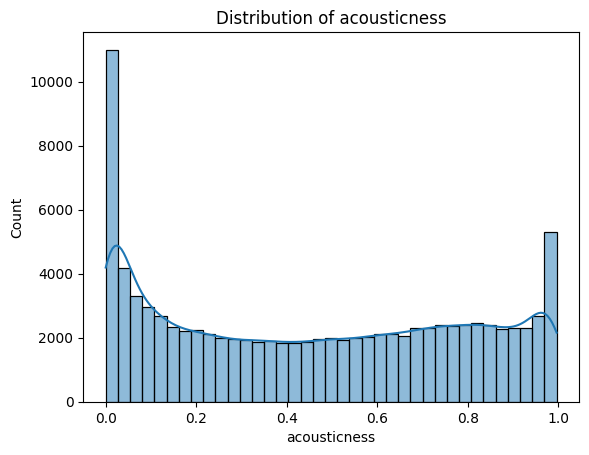

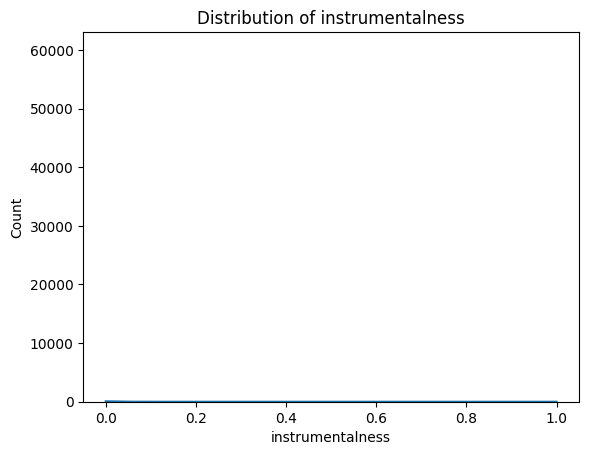

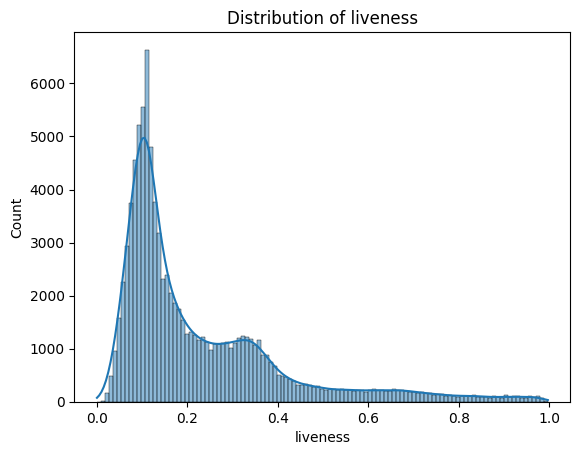

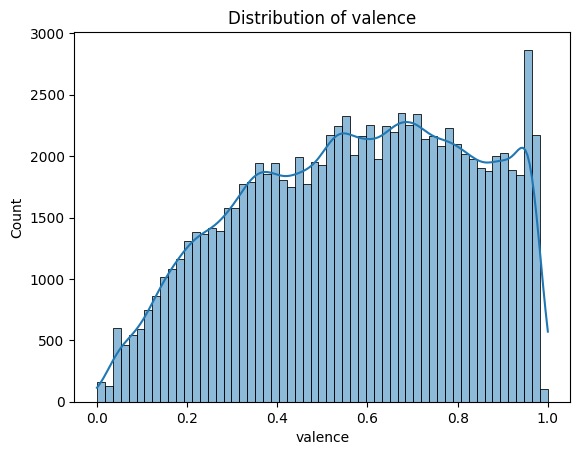

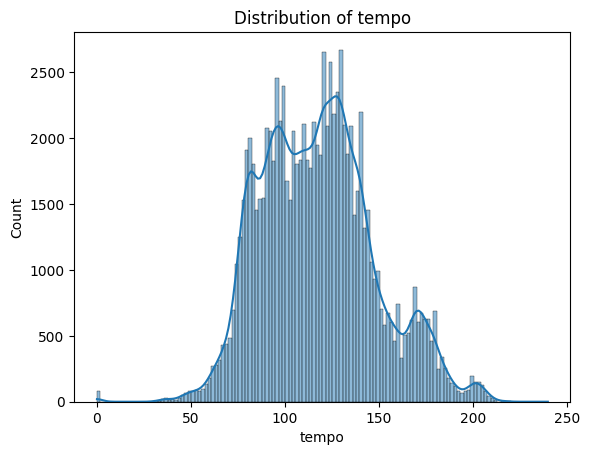

In [71]:
for col in df_clean.columns:
    plt.figure()
    sns.histplot(df_clean[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [72]:
df_clean.describe()

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,9.583700e+04,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000
mean,2.087320e+05,0.586853,0.541083,-10.157862,0.168832,0.458989,0.082145,0.224916,0.574281,117.539870
std,1.177526e+05,0.155422,0.236304,4.748798,0.275417,0.330416,0.232440,0.185829,0.248126,30.190399
min,6.373000e+03,0.000000,0.000020,-50.174000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.573330e+05,0.488000,0.365000,-12.723000,0.034100,0.133000,0.000000,0.100000,0.378000,94.829000
50%,2.040000e+05,0.605000,0.542000,-9.397000,0.046200,0.453000,0.000004,0.149000,0.589000,116.595000
75%,2.502670e+05,0.700000,0.727000,-6.692000,0.103000,0.759000,0.001300,0.302000,0.780000,135.975000
max,4.800118e+06,0.991000,1.000000,5.376000,0.968000,0.996000,1.000000,0.997000,1.000000,239.906000


Normalize the data

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)

In [74]:
import pandas as pd

scaled_df = pd.DataFrame(scaled_data, columns=df_clean.columns)
print(scaled_df.describe())

        duration_ms  danceability        energy      loudness   speechiness  \
count  9.583700e+04  9.583700e+04  9.583700e+04  9.583700e+04  9.583700e+04   
mean  -5.219509e-17  2.746173e-16  5.456759e-17  4.033257e-17 -4.982259e-17   
std    1.000005e+00  1.000005e+00  1.000005e+00  1.000005e+00  1.000005e+00   
min   -1.718520e+00 -3.775894e+00 -2.289708e+00 -8.426626e+00 -6.130100e-01   
25%   -4.365026e-01 -6.360362e-01 -7.451604e-01 -5.401685e-01 -4.891969e-01   
50%   -4.018644e-02  1.167577e-01  3.879876e-03  1.602228e-01 -4.452632e-01   
75%    3.527328e-01  7.280006e-01  7.867751e-01  7.298436e-01 -2.390291e-01   
max    3.899202e+01  2.600334e+00  1.942075e+00  3.271131e+00  2.901684e+00   

       acousticness  instrumentalness      liveness       valence  \
count  9.583700e+04      9.583700e+04  9.583700e+04  9.583700e+04   
mean   2.277604e-16     -4.033257e-17 -3.796007e-17  3.914632e-17   
std    1.000005e+00      1.000005e+00  1.000005e+00  1.000005e+00   
min   -1.389

Feature Selection

In [75]:
df_clean.columns

Index(['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'],
      dtype='object')

Clustering Techniques

In [76]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

Used the Elbow Method: Plot SSE (inertia) vs. k and find the "elbow."

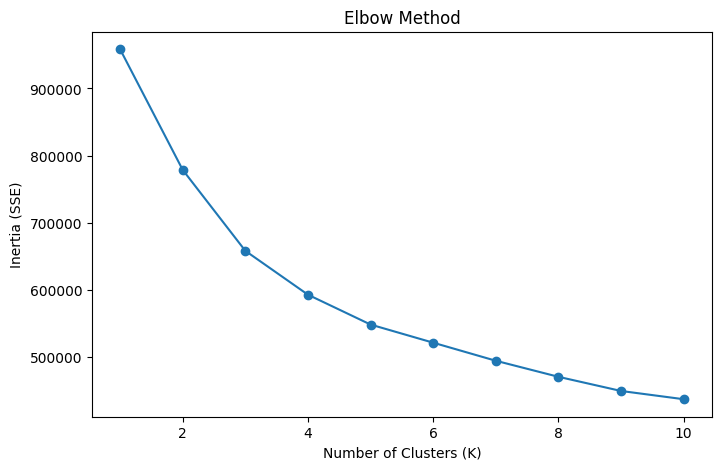

In [77]:
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method")
plt.show()

Silhouette Score to evaluate how well clusters are formed.


In [78]:
from sklearn.metrics import silhouette_score

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)

    score = silhouette_score(scaled_data, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.20317003588832805
K=3, Silhouette Score=0.24240141740661758
K=4, Silhouette Score=0.23106641264473446
K=5, Silhouette Score=0.18596876980108468


 DBSCAN (for discovering arbitrary-shaped clusters)


Cluster Evaluation and Interpretation

In [79]:
from sklearn.cluster import KMeans

k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
df_final = df_clean.copy()
df_final['cluster'] = kmeans.fit_predict(scaled_data)


In [80]:
from sklearn.metrics import davies_bouldin_score

# Calculate DBI using your scaled data and the predicted labels
db_index = davies_bouldin_score(scaled_data, df_final['cluster'])

print(f"Davies-Bouldin Index for K=3: {db_index:.4f}")

Davies-Bouldin Index for K=3: 1.5699


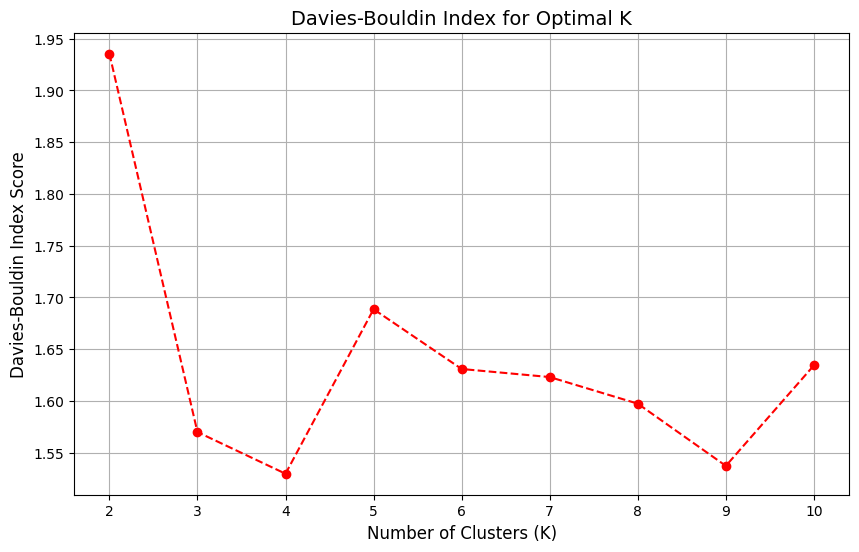

In [81]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
import matplotlib.pyplot as plt

db_scores = []
K_range = range(2, 11)  # DBI requires at least 2 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)

    # Calculate DBI for each K
    score = davies_bouldin_score(scaled_data, labels)
    db_scores.append(score)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(K_range, db_scores, marker='o', color='red', linestyle='--')
plt.title('Davies-Bouldin Index for Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Davies-Bouldin Index Score', fontsize=12)
plt.xticks(K_range)
plt.grid(True)
plt.savefig('dbi_plot.png')
plt.show()

mean values of each feature per cluster to profile clusters

In [82]:
cluster_summary = df_final.groupby('cluster').mean(numeric_only=True).round(3)
print(cluster_summary)

         duration_ms  danceability  energy  loudness  speechiness  \
cluster                                                             
0         223500.905         0.486   0.311   -13.209        0.060   
1         226568.205         0.627   0.693    -7.609        0.075   
2          97522.338         0.664   0.467   -13.364        0.830   

         acousticness  instrumentalness  liveness  valence    tempo  
cluster                                                              
0               0.750             0.169     0.182    0.413  111.933  
1               0.259             0.051     0.200    0.666  124.905  
2               0.586             0.001     0.435    0.584  100.387  


In [83]:
df['cluster'] = df_final['cluster']
df.to_csv("final_clustered_songs.csv", index=False)

In [84]:
df.groupby('cluster')['name_song'].head(5)

,name_song
0,La Java
1,En Douce
2,J'en Ai Marre
3,Ils n'ont pas ca
4,La belote
15,On M'suit
34,Je N'suis Pas Celle Que Vous Croyez
37,Dites Moi Doumergue
38,La Noce À Rebecca
43,Il N'osait Pas Se Decider


In [85]:
df.groupby('cluster')['genres'].value_counts().head(10)

cluster  genres                 
0        ['vintage taiwan pop']     1047
         ['classic israeli pop']     569
         ['chanson']                 547
         ['classic soundtrack']      456
         ['opm']                     401
         ['classic thai pop']        388
         ['indonesian pop']          361
         ['rebetiko']                353
         []                          353
         ['turkish folk']            348
Name: count, dtype: int64

In [86]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

In [87]:
import pandas as pd

pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['cluster'] = df_final['cluster']

2D scatter plots using PCA/t-SNE with color-coded cluster

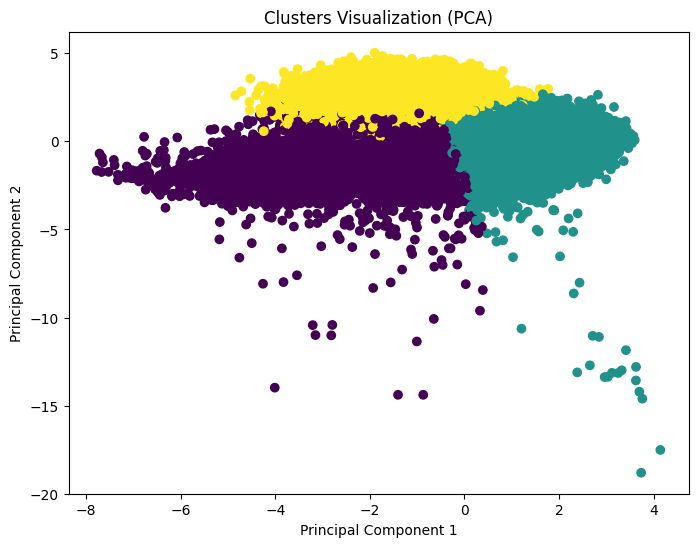

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['cluster'])
plt.title("Clusters Visualization (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Heatmaps comparing features across clusters.

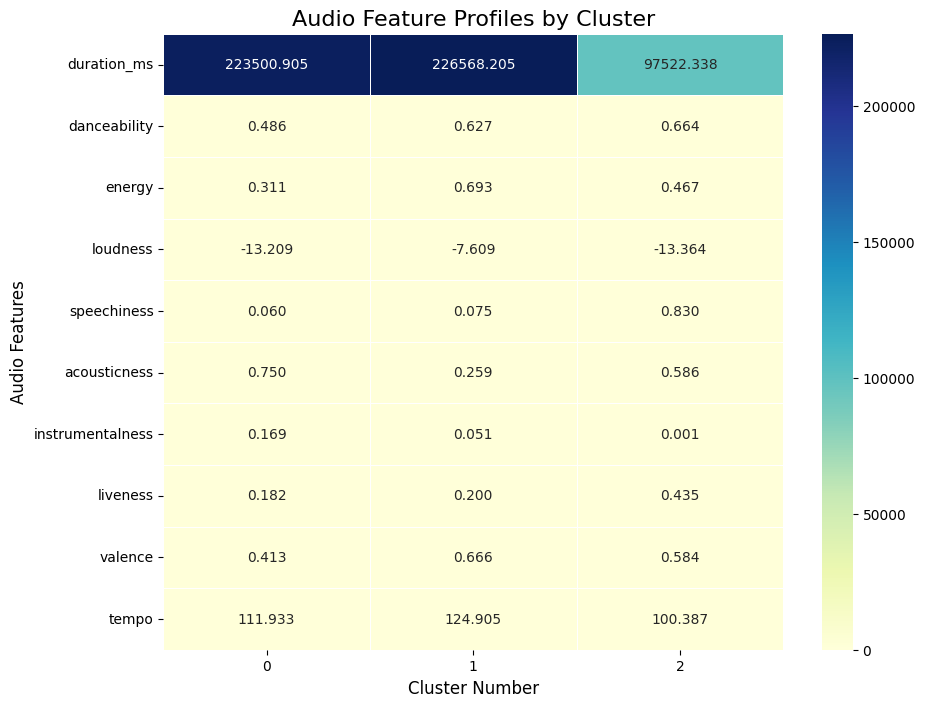

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the mean values for each feature per cluster
# Note: Using the df_final (original scale) helps with real-world interpretation,
# but using scaled_data means for the heatmap often shows differences more clearly.
cluster_summary = df_final.groupby('cluster').mean()

# 2. Transpose the dataframe so features are rows and clusters are columns
cluster_summary_t = cluster_summary.T

# 3. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cluster_summary_t, annot=True, cmap='YlGnBu', fmt='.3f', linewidths=.5)

plt.title('Audio Feature Profiles by Cluster', fontsize=16)
plt.xlabel('Cluster Number', fontsize=12)
plt.ylabel('Audio Features', fontsize=12)

# Save the figure for your project report as per guidelines
plt.savefig('cluster_heatmap.png')
plt.show()

Text(0.5, 1.0, 'Relative Feature Strength (Scaled)')

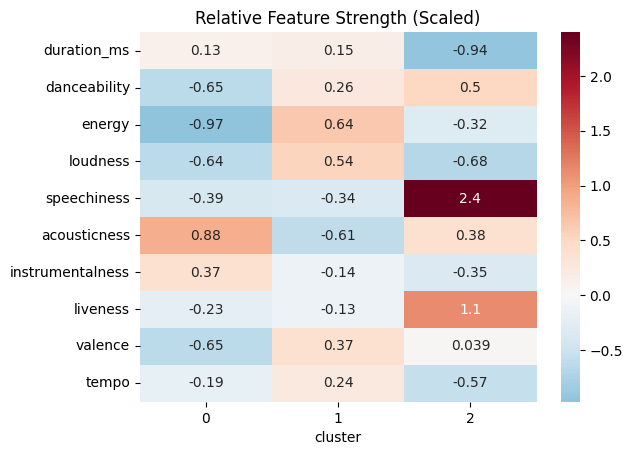

In [90]:
# Optional: Heatmap using scaled data for better visual contrast
scaled_summary = pd.DataFrame(scaled_data, columns=df_clean.columns)
scaled_summary['cluster'] = df_final['cluster']
scaled_plot_data = scaled_summary.groupby('cluster').mean().T

sns.heatmap(scaled_plot_data, annot=True, cmap='RdBu_r', center=0)
plt.title('Relative Feature Strength (Scaled)')

In [91]:
cluster_summary = df_final.groupby('cluster')[
    ['danceability', 'energy', 'acousticness',
     'instrumentalness', 'valence', 'tempo']
].mean()

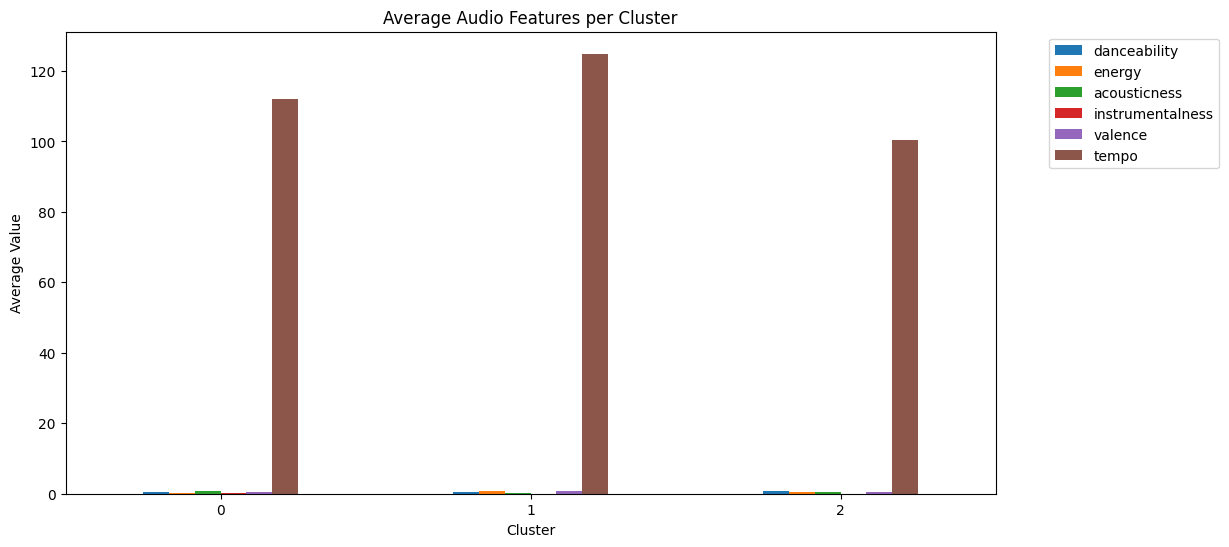

In [92]:
import matplotlib.pyplot as plt

cluster_summary.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Average Audio Features per Cluster")
plt.ylabel("Average Value")
plt.xlabel("Cluster")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

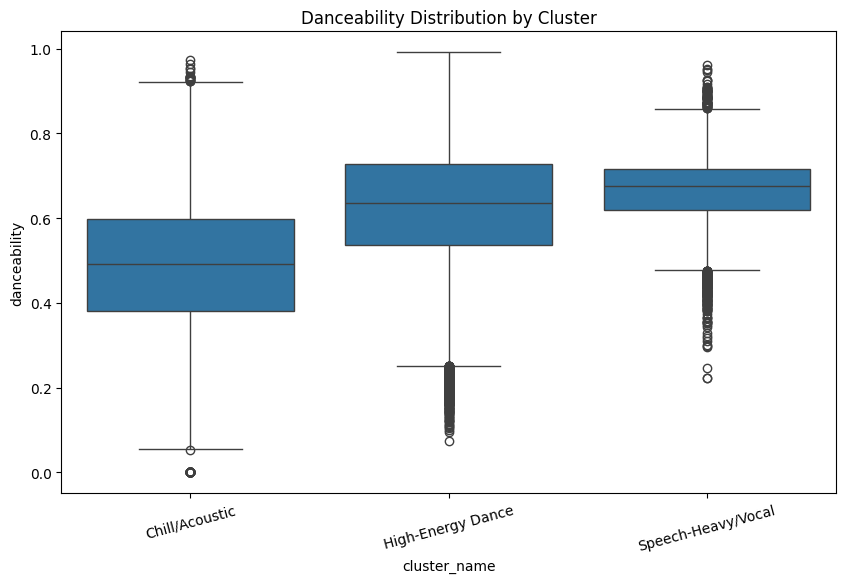

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    x='cluster_name',
    y='danceability',
    data=df_final
)

plt.title("Danceability Distribution by Cluster")
plt.xticks(rotation=15)
plt.show()

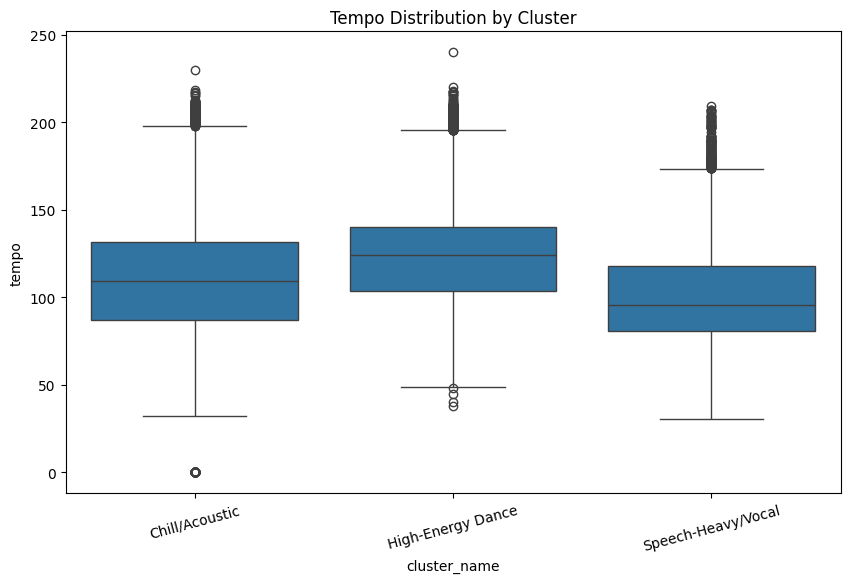

In [113]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='cluster_name',
    y='tempo',
    data=df_final
)

plt.title("Tempo Distribution by Cluster")
plt.xticks(rotation=15)
plt.show()

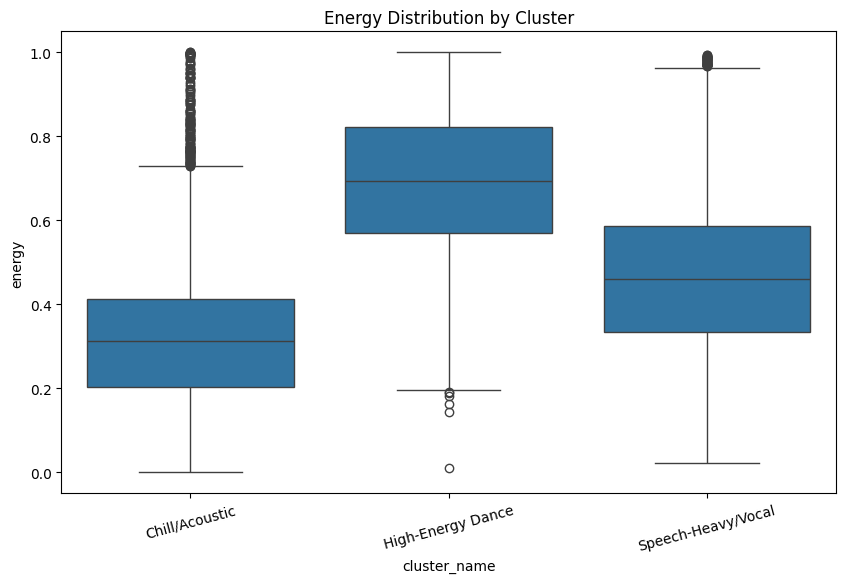

In [114]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='cluster_name',
    y='energy',
    data=df_final
)

plt.title("Energy Distribution by Cluster")
plt.xticks(rotation=15)
plt.show()

In [115]:
import pandas as pd


# 1. Calculate cluster means and overall means

cluster_means = df_final.groupby('cluster').mean(numeric_only=True)

overall_means = df_final.drop(
    columns=['cluster'],
    errors='ignore'
).mean(numeric_only=True)

# 2. Function to generate cluster names

def suggest_cluster_name(cluster_idx):

    row = cluster_means.loc[cluster_idx]

    if row['acousticness'] > overall_means['acousticness'] * 1.5:
        return "Chill/Acoustic"

    elif (
        row['energy'] > overall_means['energy']
        and row['danceability'] > 0.6
    ):
        return "High-Energy Dance"

    elif row['instrumentalness'] > overall_means['instrumentalness'] * 2:
        return "Instrumental/Focus"

    elif (
        row['valence'] > overall_means['valence']
        and row['energy'] > overall_means['energy']
    ):
        return "Upbeat/Happy"

    elif row['speechiness'] > overall_means['speechiness'] * 2:
        return "Speech-Heavy/Vocal"

    else:
        return f"Mixed Mood (Cluster {cluster_idx})"

# 3. Create cluster mapping

cluster_mapping = {
    cluster_id: suggest_cluster_name(cluster_id)
    for cluster_id in sorted(df_final['cluster'].unique())
}

# Add cluster names to df_final
df_final['cluster_name'] = df_final['cluster'].map(cluster_mapping)

# 4. Merge cluster info back into original dataframe

df['cluster'] = df_final['cluster']
df['cluster_name'] = df_final['cluster_name']

# 5. Display cluster mapping

print("\nCluster Mapping:")
print("=" * 40)

for idx, name in cluster_mapping.items():
    print(f"Cluster {idx} -> {name}")

# 6. Preview top genres in each cluster

print("\nTop Genres Per Cluster:")
print("=" * 40)

print(df.groupby('cluster')['genres'].value_counts().head(10))

# 7. Preview top tracks per cluster

for cluster in sorted(df['cluster'].unique()):

    print("\n" + "=" * 60)
    cluster_name = (df[df['cluster'] == cluster]['cluster_name'].iloc[0])

    print(f"Cluster {cluster} : {cluster_name}")
    print("=" * 60)
    top_tracks = df[df['cluster'] == cluster][[
        'name_song',
        'name_artists',
        'genres',
        'popularity_songs']].sort_values(by='popularity_songs',ascending=False).head(10)

    print(top_tracks)

# 8. Export final dataset

df.to_csv("Amazon_Music_Final_Categorized.csv",index=False)
print("Final categorized dataset exported successfully!")

# 9. Preview final dataframe

print(df.head())


Cluster Mapping:
Cluster 0 -> Chill/Acoustic
Cluster 1 -> High-Energy Dance
Cluster 2 -> Speech-Heavy/Vocal

Top Genres Per Cluster:
cluster  genres                 
0        ['vintage taiwan pop']     1047
         ['classic israeli pop']     569
         ['chanson']                 547
         ['classic soundtrack']      456
         ['opm']                     401
         ['classic thai pop']        388
         ['indonesian pop']          361
         ['rebetiko']                353
         []                          353
         ['turkish folk']            348
Name: count, dtype: int64

Cluster 0 : Chill/Acoustic
                    name_song      name_artists  \
35233                  Arcade   Duncan Laurence   
35436     Put Your Records On       Ritt Momney   
35234                  Arcade   Duncan Laurence   
34858                 Hold On  Chord Overstreet   
35505                 Control          Zoe Wees   
34650        Go Fuck Yourself          Two Feet   
34884       